# Titanic — Exploratory Data Analysis

## Objective

Analyze the Titanic passenger dataset to identify factors associated with passenger survival.

## Questions

- What was the overall survival rate?
- Was survival associated with passenger class?
- Was survival associated with sex?
- How did age relate to survival?
- What other patterns can be identified in the data?

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Dataset

The Titanic dataset contains information about 891 passengers, including their survival status, passenger class, sex, age, fare, and other characteristics.

The dataset was loaded from a public GitHub repository using Pandas.

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Data Exploration

### 3.1 Dataset Dimensions

In [49]:
df.shape

(891, 12)

### 3.2 Missing Values

In [50]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### 3.3 Descriptive Statistics

In [51]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 4. Survival Analysis

### 4.1 Overall Survival

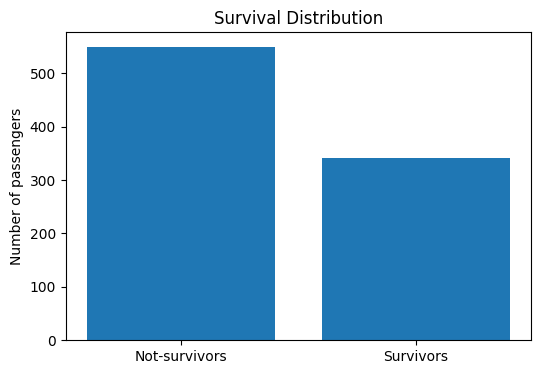

In [52]:
survival_counts = df["Survived"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(["Not-survivors", "Survivors"], survival_counts.values)
plt.title("Survival Distribution")
plt.ylabel("Number of passengers")
plt.show()

In [53]:
survival_rate = df["Survived"].value_counts(normalize=True) * 100
print(survival_rate)

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


Approximately 38.4% of the passengers survived, while 61.6% did not survive.

### 4.2 Survival by Sex

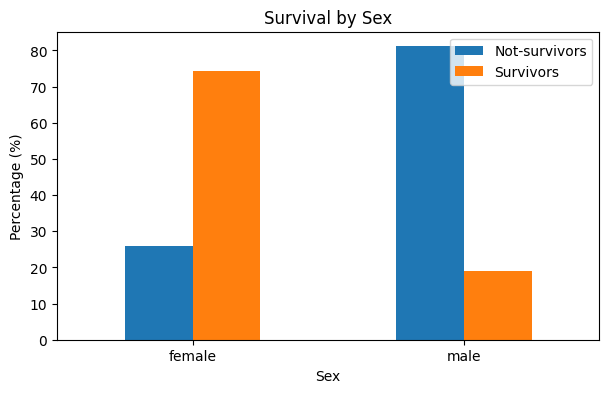

In [54]:
survival_by_sex = pd.crosstab(
    df["Sex"],
    df["Survived"],
    normalize="index"
) * 100

survival_by_sex

survival_by_sex.plot(kind="bar", figsize=(7, 4))

plt.title("Survival by Sex")
plt.xlabel("Sex")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(["Not-survivors", "Survivors"])
plt.show()

Female passengers had a substantially higher survival rate than male passengers.

### 4.3 Survival by Passenger Class

In [55]:
survival_by_class = pd.crosstab(
    df["Pclass"],
    df["Survived"],
    normalize="index"
) * 100

survival_by_class

Survived,0,1
Pclass,,
1,37.037037,62.962963
2,52.717391,47.282609
3,75.763747,24.236253


Passengers in higher classes had higher survival rates. First-class passengers had the highest survival rate, while third-class passengers had the lowest.

### 4.4 Survival by Sex and Passenger Class

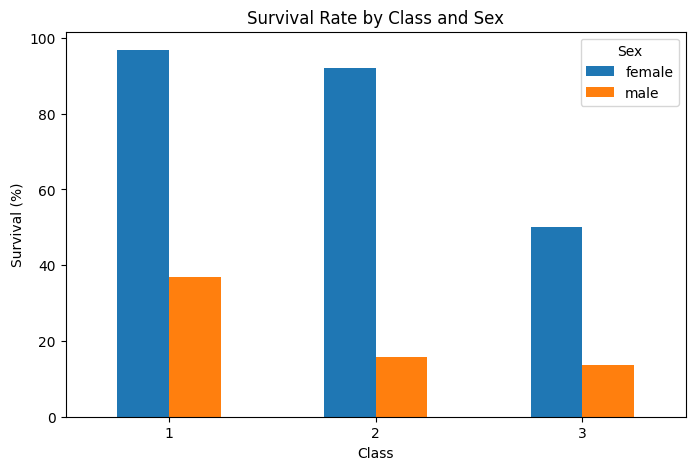

In [56]:
survival_sex_class = pd.crosstab(
    [df["Pclass"], df["Sex"]],
    df["Survived"],
    normalize="index"
) * 100

survival_sex_class

survival_sex_class_plot = (
    df.groupby(["Pclass", "Sex"])["Survived"]
    .mean()
    .mul(100)
    .unstack()
)

survival_sex_class_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Survival Rate by Class and Sex")
plt.xlabel("Class")
plt.ylabel("Survival (%)")
plt.xticks(rotation=0)
plt.legend(title="Sex")
plt.show()

Survival varied substantially by both sex and passenger class. Female passengers generally had higher survival rates than male passengers, while first-class passengers generally had higher survival rates than third-class passengers.

The combination of sex and passenger class reveals differences that are not visible when analyzing either variable separately.

### 4.5 Survival by Age

In [57]:
df["Age"].describe()

,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


In [58]:
bins = [0, 12, 17, 29, 49, 80]

labels = [
    "Children",
    "Teenager",
    "Young Adult",
    "Adult",
    "Elder Adult"
]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

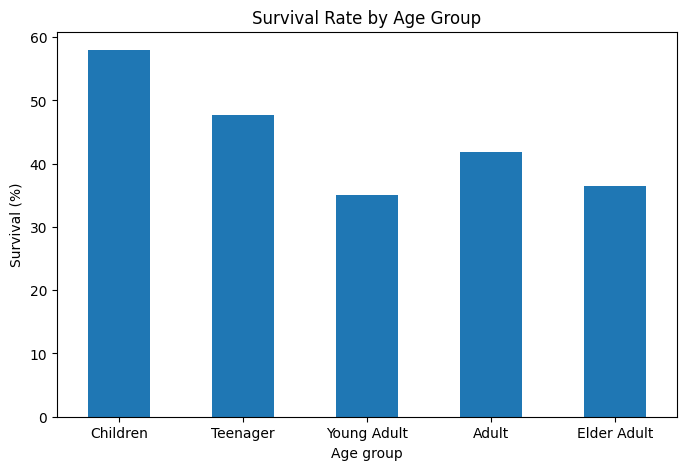

In [59]:
survival_by_age = (
    df.groupby("AgeGroup", observed=True)["Survived"]
    .mean()
    .mul(100)
)

survival_by_age

survival_by_age.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Survival Rate by Age Group")
plt.xlabel("Age group")
plt.ylabel("Survival (%)")
plt.xticks(rotation=0)

plt.show()

### 4.6 Survival by Age, Sex and Passenger Class

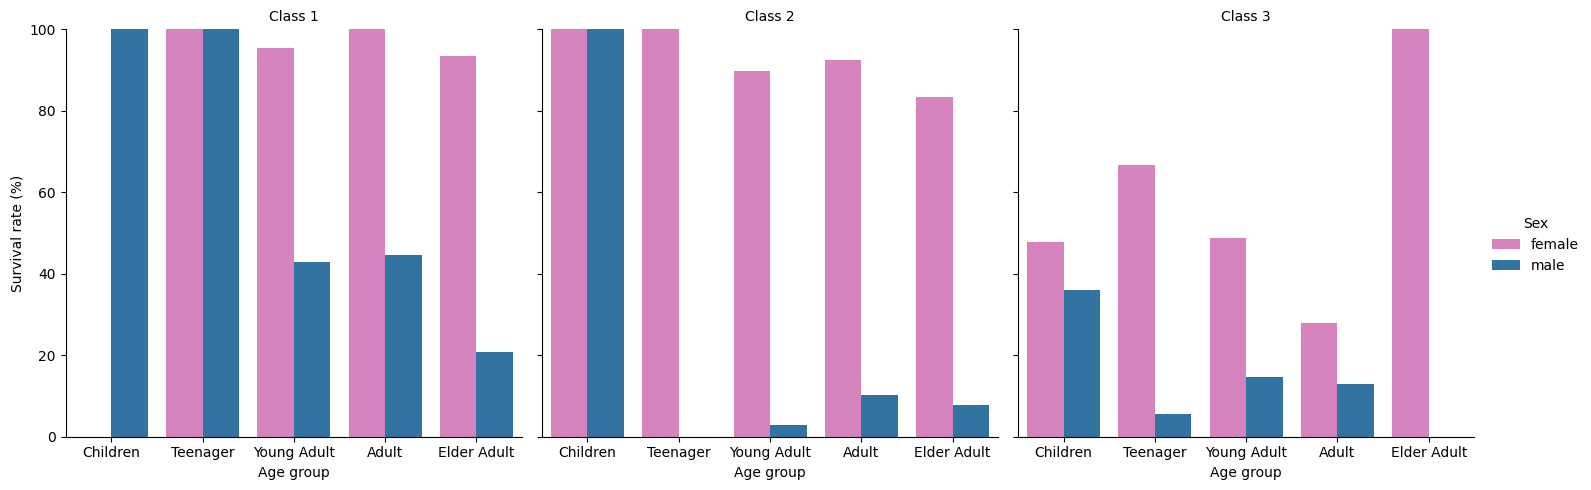

In [60]:
survival_sex_class_age = (
    df.groupby(
        ["AgeGroup", "Pclass", "Sex"],
        observed=True
    )["Survived"]
    .mean()
    .mul(100)
)

survival_sex_class_age

df_plot = survival_sex_class_age.reset_index(name="SurvivalRate")

g = sns.catplot(
    data=df_plot,
    x="AgeGroup",
    y="SurvivalRate",
    hue="Sex",
    col="Pclass",
    kind="bar",
    palette={"male": "#1f77b4", "female": "#e377c2"}
)

g.set_axis_labels("Age group", "Survival rate (%)")
g.set_titles("Class {col_name}")
g.set(ylim=(0, 100))

plt.show()

Survival differences were strongly influenced by the combination of age, sex, and passenger class. Female passengers generally had higher survival rates, while male passengers, particularly those in second and third class, had substantially lower survival rates.

Some age-sex-class combinations contain very few observations, so their percentages should be interpreted cautiously.

## 5. Conclusions

- Approximately 38.4% of the passengers in the dataset survived the Titanic disaster.
- Sex showed a strong association with survival, with female passengers having substantially higher survival rates than male passengers.
- Passenger class was also strongly associated with survival. Higher-class passengers generally had higher survival rates than passengers in lower classes.
- The combination of sex and passenger class revealed even larger differences in survival, with female passengers generally having higher survival rates than male passengers across classes.
- Age showed a less consistent association with survival. Survival rates varied across age groups, but there was no clear pattern indicating that younger passengers were always more likely to survive.
- The analysis shows that survival was associated with multiple variables, particularly sex and passenger class. However, these relationships should not be interpreted as causal based on this exploratory analysis alone.